# Diseño SFV — Laboratorio TABAREC

**Proyecto:** SFV_LABORATORIO  
**Medidor:** HOL-100504639 (División 3 — uso comercial / laboratorio)  
**Fuente:** Recibo CEDENAR Febrero 2026

**Enfoque de este diseño:**
1. Análisis energético separado: **energía activa + contribución** vs **alumbrado público**.
2. Consumo base **sin ascensor** (~$400 000 COP/mes retirados del medidor).
3. SFV dimensionado para **cubrir la demanda del laboratorio** y generar **excedente para compensar el alumbrado público** del mismo medidor.

## Registro de avance

| # | Etapa | Estado | Notas |
|---|-------|--------|-------|
| 0 | Datos del recibo | ✅ | CEDENAR Feb/2026 |
| 1 | Alumbrado público — análisis | ✅ | Cargo proporcional; cubierto con excedente |
| 2 | Consumo sin ascensor | ✅ | Retiro de ~334 kWh/mes |
| 3 | Análisis energético | ✅ | Autoconsumo vs alumbrado (excedente) |
| 4 | Excedente alumbrado público | ✅ | ~$170K/mes — compensación vía exportación |
| 5 | Dimensionamiento SFV — 710 Wp | ✅ | 26 módulos + 2× 8K |
| 5b | Alternativa 650 Wp | ✅ | Comparación de equipos |

---
## Etapa 0 — Datos del recibo CEDENAR (Laboratorio)

| Campo | Valor |
|-------|-------|
| Empresa | CEDENAR S.A. E.S.P. |
| Titular | Luis Carlos Millán Tabares |
| Dirección | Cra 28 Calle 17-39, Div 3, Edif. TABAREC |
| Medidor | **HOL-100504639** |
| Tipo de uso | No residencial — Comercial |
| Consumo período | **1 580 kWh** |
| CUv (energía activa) | **$883,72 COP/kWh** |
| Valor energía activa | $1 396 277,60 |
| Contribución (20%) | $279 255,52 |
| Alumbrado público | $214 802,00 |
| **Total a pagar** | **$1 890 340 COP** |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

recibo = {
    "medidor": "HOL-100504639",
    "ubicacion": "Laboratorio — Div 3, Edif. TABAREC",
    "mes_facturado": "Febrero 2026",
    "consumo_kwh": 1580,
    "cuv_cop_kwh": 883.72,
    "valor_energia_cop": 1_396_277.60,
    "contribucion_cop": 279_255.52,
    "alumbrado_publico_cop": 214_802.00,
    "total_pagar_cop": 1_890_340,
}

# Referencia comparativa — zonas comunes (solo tarifa alumbrado)
recibo_zc = {
    "medidor": "HEX-16536166",
    "consumo_mes_ref": 366,
    "alumbrado_publico_cop": 51_117,
}

print(f"Laboratorio — Medidor: {recibo['medidor']}")
print(f"Consumo: {recibo['consumo_kwh']:,} kWh  |  Total: ${recibo['total_pagar_cop']:,} COP")
print(f"Alumbrado público (Feb): ${recibo['alumbrado_publico_cop']:,} COP")


Laboratorio — Medidor: HOL-100504639
Consumo: 1,580 kWh  |  Total: $1,890,340 COP
Zonas comunes — Medidor: HEX-16536166  |  ~4,504 kWh/año


---
## Etapa 1 — Alumbrado público: qué cobran y cómo lo cubre el excedente

CEDENAR factura el **alumbrado público** como cargo **proporcional al consumo** del medidor (~$136/kWh consumido). No es energía del local; es un aporte municipal.

En compensación **AGPE**, cada kWh exportado solo compensa importado a tarifa **CUv** ($883,72). Por eso el SFV debe generar **excedente** adicional para que, vía exportación, también se cubra el alumbrado público del medidor del laboratorio.

| Medidor | Consumo | Alumbrado | $/kWh consumido |
|---------|---------|-----------|-----------------|
| Laboratorio (HOL) | 1 580 kWh | $214 802 | **$135,95** |
| Zonas comunes (HEX) | 366 kWh | $51 117 | **$139,66** *(referencia)* |

**Energía + contribución:** $883,72 × 1,20 = **$1 060,46/kWh**  
**Factura total:** **$1 196,41/kWh** → factor diseño **1,354** (total ÷ CUv)

In [2]:
CUV = recibo["cuv_cop_kwh"]
PCT_CONTRIBUCION = recibo["contribucion_cop"] / recibo["valor_energia_cop"]

# Tarifas por kWh
alumbrado_lab_kwh = recibo["alumbrado_publico_cop"] / recibo["consumo_kwh"]
alumbrado_zc_kwh = recibo_zc["alumbrado_publico_cop"] / recibo_zc["consumo_mes_ref"]
costo_energia_kwh = CUV * (1 + PCT_CONTRIBUCION)  # solo energía + contribución
costo_total_kwh = costo_energia_kwh + alumbrado_lab_kwh

tabla_alum = pd.DataFrame({
    "Medidor": ["Laboratorio (HOL)", "Zonas comunes (HEX)"],
    "Alumbrado COP": [f"${recibo['alumbrado_publico_cop']:,.0f}", f"${recibo_zc['alumbrado_publico_cop']:,.0f}"],
    "Alumbrado $/kWh": [f"${alumbrado_lab_kwh:.2f}", f"${alumbrado_zc_kwh:.2f}"],
    "Energía+contrib $/kWh": [f"${costo_energia_kwh:.2f}", f"${costo_energia_kwh:.2f}"],
    "% alumbrado/total": [
        f"{recibo['alumbrado_publico_cop']/recibo['total_pagar_cop']*100:.1f}%",
        "—",
    ],
})

print("=== Comparación alumbrado público ===")
print(tabla_alum.to_string(index=False))
print(f"\nCosto energético (sin alumbrado): ${costo_energia_kwh:,.2f}/kWh")
print(f"Costo total factura (con alumbrado): ${costo_total_kwh:,.2f}/kWh")


=== Comparación alumbrado público ===
            Medidor Alumbrado COP Alumbrado $/kWh Energía+contrib $/kWh % alumbrado/total
  Laboratorio (HOL)      $214,802         $135.95              $1060.46             11.4%
Zonas comunes (HEX)       $51,117         $139.66              $1060.46             11.6%

Costo energético (sin alumbrado): $1,060.46/kWh
Costo total factura (con alumbrado): $1,196.41/kWh


---
## Etapa 2 — Retiro del ascensor

El recibo actual **incluye** el ascensor del edificio. Para el diseño se modela su retiro del medidor del laboratorio.

| Parámetro | Valor |
|-----------|-------|
| Costo real ascensor | **~$400 000 COP/mes** |
| kWh equivalente | ~334 kWh/mes (~4 012 kWh/año) |
| Referencia teórica motor 7,5 kW | ~176 kWh/mes |

In [4]:
COSTO_ASCENSOR_MES = 400_000
TARIFA_TOTAL_KWH = recibo["total_pagar_cop"] / recibo["consumo_kwh"]
KWH_ASCENSOR_MES = round(COSTO_ASCENSOR_MES / TARIFA_TOTAL_KWH, 1)

consumo_mensual_recibo = {
    "Ago": 1521, "Sep": 1657, "Oct": 1572, "Nov": 1594,
    "Dic": 1591, "Ene": 1555, "Feb": 1580,
}
df = pd.DataFrame({"mes": list(consumo_mensual_recibo.keys()),
                   "kwh_recibo": list(consumo_mensual_recibo.values())})
df["kwh_diseno"] = df["kwh_recibo"] - KWH_ASCENSOR_MES

consumo_prom_recibo = df["kwh_recibo"].mean()
consumo_prom_diseno = df["kwh_diseno"].mean()
consumo_anual_diseno = consumo_prom_diseno * 12

print(f"Ascensor: ${COSTO_ASCENSOR_MES:,}/mes ≈ {KWH_ASCENSOR_MES} kWh/mes")
print(f"\n=== Consumo de diseño (SIN ascensor) ===")
print(f"Promedio mensual:  {consumo_prom_diseno:,.1f} kWh/mes")
print(f"Anual estimado:    {consumo_anual_diseno:,.0f} kWh/año")
print(f"Reducción vs recibo: -{KWH_ASCENSOR_MES/consumo_prom_recibo*100:.1f}%")


Ascensor: $400,000/mes ≈ 334.3 kWh/mes

=== Consumo de diseño (SIN ascensor) ===
Promedio mensual:  1,247.1 kWh/mes
Anual estimado:    14,966 kWh/año
Reducción vs recibo: -21.1%


---
## Etapa 3 — Análisis energético (componente energía vs alumbrado)

Se desglosa la factura en dos bloques:
- **Autoconsumo SFV:** energía activa + contribución (20 %).
- **Excedente SFV:** exportación para cubrir **alumbrado público**.

In [11]:
ALUMBRADO_POR_KWH = alumbrado_lab_kwh

def factura_energia(kwh):
    """Solo energía activa + contribución (sin alumbrado)."""
    energia = kwh * CUV
    contrib = energia * PCT_CONTRIBUCION
    return {"kwh": kwh, "energia": round(energia), "contrib": round(contrib),
            "total_energia": round(energia + contrib),
            "alumbrado": round(kwh * ALUMBRADO_POR_KWH)}

def factura_completa(kwh):
    f = factura_energia(kwh)
    f["total_factura"] = f["total_energia"] + f["alumbrado"]
    return f

# Promedio mensual
f_con = factura_completa(consumo_prom_recibo)
f_sin = factura_completa(consumo_prom_diseno)
f_asc = factura_completa(KWH_ASCENSOR_MES)
f_asc["total_factura"] = COSTO_ASCENSOR_MES

comparacion = pd.DataFrame({
    "Concepto": ["kWh/mes", "Energía activa", "Contribución (20%)", "Alumbrado público", "TOTAL factura"],
    "Con ascensor": [
        f"{consumo_prom_recibo:,.0f}", f"${f_con['energia']:,}", f"${f_con['contrib']:,}",
        f"${f_con['alumbrado']:,}", f"${f_con['total_factura']:,}",
    ],
    "Sin ascensor (diseño)": [
        f"{consumo_prom_diseno:,.0f}", f"${f_sin['energia']:,}", f"${f_sin['contrib']:,}",
        f"${f_sin['alumbrado']:,}", f"${f_sin['total_factura']:,}",
    ],
    "Solo ascensor": [
        f"{KWH_ASCENSOR_MES:.0f}", f"${f_asc['energia']:,}", f"${f_asc['contrib']:,}",
        f"${f_asc['alumbrado']:,}", f"${COSTO_ASCENSOR_MES:,}",
    ],
})

print("=" * 72)
print("FACTURA MENSUAL — desglose energético vs alumbrado")
print("=" * 72)
print(comparacion.to_string(index=False))

print(f"\n--- Componentes del diseño SFV ---")
print(f"Autoconsumo (energía+contrib): ${f_sin['total_energia']:,}/mes  (${f_sin['total_energia']*12:,.0f}/año)")
print(f"Excedente objetivo (alumbrado): ${f_sin['alumbrado']:,}/mes  (${f_sin['alumbrado']*12:,.0f}/año)")
print(f"Factura objetivo con SFV:        $0 COP/mes")


FACTURA MENSUAL — desglose energético vs alumbrado
          Concepto Con ascensor Sin ascensor (diseño) Solo ascensor
           kWh/mes        1,581                 1,247           334
    Energía activa   $1,397,540            $1,102,112      $295,428
Contribución (20%)     $279,508              $220,422       $59,086
 Alumbrado público     $214,996              $169,548       $45,448
     TOTAL factura   $1,892,044            $1,492,083      $400,000

--- Componentes del diseño SFV ---
Autoconsumo (energía+contrib): $1,322,535/mes  ($15,870,420/año)
Excedente objetivo (alumbrado): $169,548/mes  ($2,034,576/año)
Factura objetivo con SFV:        $0 COP/mes


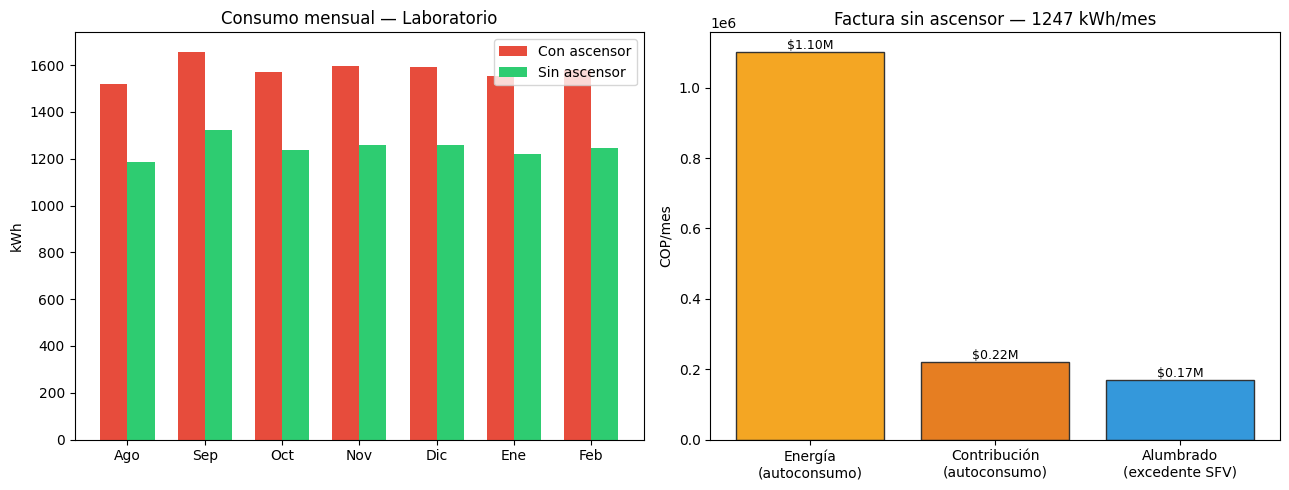

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: consumo mensual
ax = axes[0]
x = range(len(df))
w = 0.35
ax.bar([i-w/2 for i in x], df["kwh_recibo"], width=w, label="Con ascensor", color="#e74c3c")
ax.bar([i+w/2 for i in x], df["kwh_diseno"], width=w, label="Sin ascensor", color="#2ecc71")
ax.set_xticks(x); ax.set_xticklabels(df["mes"])
ax.set_ylabel("kWh"); ax.set_title("Consumo mensual — Laboratorio")
ax.legend()

# Gráfico 2: desglose factura sin ascensor
ax2 = axes[1]
labels = ["Energía\n(autoconsumo)", "Contribución\n(autoconsumo)", "Alumbrado\n(excedente SFV)"]
vals = [f_sin["energia"], f_sin["contrib"], f_sin["alumbrado"]]
colors = ["#f4a623", "#e67e22", "#3498db"]
bars = ax2.bar(labels, vals, color=colors, edgecolor="#333")
ax2.set_ylabel("COP/mes")
ax2.set_title(f"Factura sin ascensor — {consumo_prom_diseno:.0f} kWh/mes")
for b, v in zip(bars, vals):
    ax2.text(b.get_x()+b.get_width()/2, v+8000, f"${v/1e6:.2f}M", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


---
## Etapa 4 — Excedente para alumbrado público

El SFV del laboratorio cubre:
1. **Autoconsumo** — demanda eléctrica del local (sin ascensor).
2. **Excedente exportado** — compensa el **alumbrado público** del medidor HOL-100504639.

En AGPE, la exportación solo valora a **CUv**; por eso se sobredimensiona con el factor factura total/CUv ≈ **1,354**.

| Concepto | Sin ascensor (promedio) | Anual |
|----------|----------------------|-------|
| Autoconsumo (energía+contrib) | ~$1 322 535/mes | ~$15,9 M COP |
| **Excedente (alumbrado público)** | **~$169 548/mes** | **~$2,0 M COP** |
| **Factura objetivo** | **$0** | **$0** |

In [13]:
alumbrado_mes_diseno = f_sin["alumbrado"]
alumbrado_anual_diseno = alumbrado_mes_diseno * 12
# kWh de exportación equivalentes (compensación solo a CUv)
kwh_excedente_alumbrado = alumbrado_anual_diseno / CUV

print("=== Excedente para alumbrado público (medidor laboratorio) ===")
print(f"Alumbrado mensual (sin ascensor):  ${alumbrado_mes_diseno:,} COP/mes")
print(f"Alumbrado anual:                   ${alumbrado_anual_diseno:,.0f} COP/año")
print(f"Tarifa alumbrado:                  ${ALUMBRADO_POR_KWH:.2f}/kWh consumido")
print(f"kWh exportados equiv. (÷ CUv):     {kwh_excedente_alumbrado:,.0f} kWh/año")
print(f"\n→ Este excedente NO va a zonas comunes; cubre el alumbrado del mismo medidor.")


=== Excedente para alumbrado público (medidor laboratorio) ===
Alumbrado mensual (sin ascensor):  $169,548 COP/mes
Alumbrado anual:                   $2,034,576 COP/año
Tarifa alumbrado:                  $135.95/kWh consumido
kWh exportados equiv. (÷ CUv):     2,302 kWh/año

→ Este excedente NO va a zonas comunes; cubre el alumbrado del mismo medidor.


---
## Etapa 5 — Dimensionamiento SFV

**Objetivo:** factura **$0** en el medidor del laboratorio (energía + contribución + alumbrado público).

$$kWh_{objetivo} = Consumo_{proyectado} \times \frac{Costo\ total/kWh}{CUv} \times Margenes$$

| Parámetro | Valor |
|-----------|-------|
| Factor factura/CUv | **1,354** (contrib + alumbrado) |
| HSP | 4,8 h/día |
| PR | 0,80 |
| Módulo | 710 Wp |
| Margen nueva carga | +10% |
| Suba tarifa | +5% |
| Margen seguridad | +10% |

**Equipos:** Huawei SUN2000-8/10K-LC0

In [16]:
FACTOR_NUEVA_CARGA = 1.10
FACTOR_SUBA_TARIFA = 1.05
MARGEN_SEGURIDAD = 1.10
FACTOR_ENERGIA = 1 + PCT_CONTRIBUCION          # 1.20 — autoconsumo
FACTOR_FACTURA_TOTAL = costo_total_kwh / CUV   # ~1.354 — incluye alumbrado
HSP = 4.8
PR = 0.80
modulo_wp = 710

def dimensionar(kwh_anual, potencia_wp=710):
    ppico = kwh_anual / (HSP * 365 * PR)
    n = math.ceil(ppico * 1000 / potencia_wp)
    prod = n * potencia_wp / 1000 * HSP * 365 * PR
    return {"n_modulos": n, "kwp": round(n * potencia_wp / 1000, 2), "prod_kwh": round(prod)}

lab_anual = consumo_anual_diseno
lab_proyectado = lab_anual * FACTOR_NUEVA_CARGA
modulo_wp = 710

# Solo energía (referencia)
kwh_solo_energia = lab_proyectado * FACTOR_ENERGIA * FACTOR_SUBA_TARIFA * MARGEN_SEGURIDAD
# Factura cero total (autoconsumo + excedente alumbrado)
kwh_generar = lab_proyectado * FACTOR_FACTURA_TOTAL * FACTOR_SUBA_TARIFA * MARGEN_SEGURIDAD

dim = dimensionar(kwh_generar, modulo_wp)
dim_energia = dimensionar(kwh_solo_energia, modulo_wp)

print("=" * 65)
print("DIMENSIONAMIENTO SFV — LABORATORIO + EXCEDENTE ALUMBRADO PÚBLICO")
print("=" * 65)
print(f"\nConsumo lab (sin ascensor):        {lab_anual:,.0f} kWh/año")
print(f"Lab proyectado (+10% carga):       {lab_proyectado:,.0f} kWh/año")
print(f"Factor factura/CUv:                {FACTOR_FACTURA_TOTAL:.3f}")
print(f"Generación objetivo (factura $0):  {kwh_generar:,.0f} kWh/año")
print(f"\n--- Sistema propuesto ---")
print(f"Paneles:  {dim['n_modulos']} × {modulo_wp} Wp = {dim['kwp']} kWp")
print(f"Producción estimada:               {dim['prod_kwh']:,} kWh/año")
print(f"\n--- Referencia: solo energía (sin excedente alumbrado) ---")
print(f"Generación objetivo:               {kwh_solo_energia:,.0f} kWh/año → {dim_energia['n_modulos']} paneles ({dim_energia['kwp']} kWp)")

excedente_kwh = dim["prod_kwh"] - lab_proyectado
print(f"\n--- Balance anual estimado ---")
print(f"Producción:                        {dim['prod_kwh']:,} kWh")
print(f"Autoconsumo laboratorio:           {lab_proyectado:,.0f} kWh")
print(f"Excedente exportado:               {excedente_kwh:,.0f} kWh")
print(f"Equiv. para alumbrado (÷ CUv):     {kwh_excedente_alumbrado:,.0f} kWh/año")
print(f"Alumbrado a cubrir:                ${alumbrado_anual_diseno:,.0f} COP/año")


DIMENSIONAMIENTO SFV — LABORATORIO + EXCEDENTE ALUMBRADO PÚBLICO

Consumo lab (sin ascensor):        14,966 kWh/año
Lab proyectado (+10% carga):       16,462 kWh/año
Factor factura/CUv:                1.354
Generación objetivo (factura $0):  25,742 kWh/año

--- Sistema propuesto ---
Paneles:  26 × 710 Wp = 18.46 kWp
Producción estimada:               25,874 kWh/año

--- Referencia: solo energía (sin excedente alumbrado) ---
Generación objetivo:               22,816 kWh/año → 23 paneles (16.33 kWp)

--- Balance anual estimado ---
Producción:                        25,874 kWh
Autoconsumo laboratorio:           16,462 kWh
Excedente exportado:               9,412 kWh
Equiv. para alumbrado (÷ CUv):     2,302 kWh/año
Alumbrado a cubrir:                $2,034,576 COP/año


In [15]:
# Selección inversor Huawei
INVERSORES = {
    "SUN2000-8K-LC0":  {"pac_kw": 8,  "vmax": 1080, "mppt": 2, "istr_max": 16},
    "SUN2000-10K-LC0": {"pac_kw": 10, "vmax": 1080, "mppt": 2, "istr_max": 16},
}

kwp = dim["kwp"]
opciones = []
for nombre, inv in INVERSORES.items():
    for n_inv in range(1, 5):
        pac = n_inv * inv["pac_kw"]
        ratio = kwp / pac
        opciones.append({
            "Inversor": f"{n_inv}× {nombre}",
            "Pac (kW)": pac,
            "Ratio DC/AC": round(ratio, 2),
            "Clipping ~%": max(0, round((ratio - 1.1) / ratio * 100, 1)) if ratio > 1.1 else 0,
        })

df_inv = pd.DataFrame(opciones)
print("\n=== Opciones inversor (Huawei LC0) ===")
print(df_inv[df_inv["Ratio DC/AC"].between(0.9, 1.3)].to_string(index=False))
print("\nRecomendado: 2 × SUN2000-8K-LC0 (18,5 kWp / 16 kW → ratio 1,15)")



=== Opciones inversor (Huawei LC0) ===
          Inversor  Pac (kW)  Ratio DC/AC  Clipping ~%
 2× SUN2000-8K-LC0        16         1.15          4.7
2× SUN2000-10K-LC0        20         0.92          0.0

Recomendado: 2 × SUN2000-8K-LC0 (18,5 kWp / 16 kW → ratio 1,15)


---
## Etapa 5b — Alternativa: módulos **650 Wp**

Misma demanda y mismos márgenes que la Etapa 5; solo cambia la potencia del módulo.

| Parámetro | 710 Wp (base) | 650 Wp (alternativa) |
|-----------|---------------|----------------------|
| Generación objetivo | 25 742 kWh/año | 25 742 kWh/año |
| HSP / PR | 4,8 / 0,80 | 4,8 / 0,80 |
| Inversor | Huawei SUN2000-8/10K-LC0 | Huawei SUN2000-8/10K-LC0 |

In [ ]:
MODULOS_WP = [710, 650]
resultados = []

for wp in MODULOS_WP:
    d0 = dimensionar(kwh_generar, wp)
    d1 = dimensionar(kwh_solo_energia, wp)
    excedente = d0["prod_kwh"] - lab_proyectado
    resultados.append({
        "Módulo": f"{wp} Wp",
        "Objetivo kWh/año": f"{kwh_generar:,.0f}",
        "Paneles (factura $0)": d0["n_modulos"],
        "Potencia pico": f"{d0['kwp']} kWp",
        "Producción est.": f"{d0['prod_kwh']:,} kWh/año",
        "Excedente": f"{excedente:,.0f} kWh/año",
        "Paneles (solo energía)": d1["n_modulos"],
    })

df_modulos = pd.DataFrame(resultados)

print("=" * 70)
print("COMPARACIÓN MÓDULOS — LABORATORIO + EXCEDENTE ALUMBRADO")
print("=" * 70)
print(df_modulos.to_string(index=False))

dim_650 = dimensionar(kwh_generar, 650)
print(f"\n--- Alternativa 650 Wp (factura $0) ---")
print(f"Paneles:  {dim_650['n_modulos']} × 650 Wp = {dim_650['kwp']} kWp")
print(f"Producción estimada:  {dim_650['prod_kwh']:,} kWh/año")
print(f"vs 710 Wp:  {dim['n_modulos']} paneles / {dim['kwp']} kWp / {dim['prod_kwh']:,} kWh/año")
print(f"Diferencia: +{dim_650['n_modulos'] - dim['n_modulos']} paneles, "
      f"{dim_650['kwp'] - dim['kwp']:+.2f} kWp, "
      f"{dim_650['prod_kwh'] - dim['prod_kwh']:+,} kWh/año")


In [ ]:
# Inversor — alternativa 650 Wp
kwp_650 = dim_650["kwp"]
opciones_650 = []
for nombre, inv in INVERSORES.items():
    for n_inv in range(1, 5):
        pac = n_inv * inv["pac_kw"]
        ratio = kwp_650 / pac
        opciones_650.append({
            "Inversor": f"{n_inv}× {nombre}",
            "Pac (kW)": pac,
            "Ratio DC/AC": round(ratio, 2),
            "Clipping ~%": max(0, round((ratio - 1.1) / ratio * 100, 1)) if ratio > 1.1 else 0,
        })

df_inv_650 = pd.DataFrame(opciones_650)
print("=== Inversor — alternativa 650 Wp ===")
print(df_inv_650[df_inv_650["Ratio DC/AC"].between(0.9, 1.3)].to_string(index=False))
print(f"\nRecomendado: 2 × SUN2000-8K-LC0 ({kwp_650} kWp / 16 kW → ratio {kwp_650/16:.2f})")


### Resumen alternativa 650 Wp

| Concepto | 710 Wp | **650 Wp** |
|----------|--------|------------|
| Paneles | 26 | **29** |
| Potencia pico | 18,46 kWp | **18,85 kWp** |
| Producción estimada | ~25 874 kWh/año | **~26 420 kWh/año** |
| Inversor recomendado | 2 × SUN2000-8K-LC0 | **2 × SUN2000-8K-LC0** |
| Factura objetivo | $0 | **$0** |

Con 650 Wp se necesitan **3 paneles más** (29 vs 26) para alcanzar la generación objetivo; la potencia pico es similar (+0,4 kWp) con ~550 kWh/año adicionales de producción.

---
## Resumen ejecutivo

| Concepto | Valor |
|----------|-------|
| Medidor laboratorio | HOL-100504639 |
| Consumo diseño (sin ascensor) | **~1 247 kWh/mes** (14 966 kWh/año) |
| Autoconsumo (energía+contrib) | **~$1,32 M COP/mes** |
| Excedente objetivo (alumbrado público) | **~$170 000 COP/mes** |
| **Sistema SFV (710 Wp)** | **26 × 710 Wp = 18,5 kWp** |
| Alternativa 650 Wp | 29 × 650 Wp = 18,85 kWp *(ver Etapa 5b)* |
| **Inversor** | **2 × Huawei SUN2000-8K-LC0** |
| Producción estimada | **~25 900 kWh/año** |
| **Factura objetivo** | **$0 COP/mes** (energía + contribución + alumbrado) |

> El ascensor (~$400K/mes) se retira del medidor antes del dimensionamiento. El excedente cubre **alumbrado público del laboratorio**, no el medidor de zonas comunes.